# Actividad 2 — Lectura · NASA POWER

**Fuentes:**
- `sources/nasa/nasapowercrudo/` — Archivo crudo original descargado de la API NASA POWER
- `sources/nasa/nasapower/` — 102 CSVs pre-procesados por provincia (trabajo de tu compañero en Google Colab)

**Institución:** NASA — POWER (Prediction Of Worldwide Energy Resources), modelo MERRA-2

## Objetivo
Documentar el origen de los datos climáticos en dos niveles:
1. El formato nativo de NASA POWER (no legible directamente por pandas)
2. El formato pre-procesado por provincia (legible, con columnas departamento/provincia)

Luego leer los 102 CSVs, transformar WIDE→LONG y exportar el dataset raw.


### Configuración inicial
Carga el `pipeline_config.json` generado en la Actividad 1 y las librerías necesarias.


In [1]:
import os, sys, json, glob, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Asegurar raiz del proyecto
while not os.path.exists('pipeline/config/pipeline_config.json'):
    os.chdir('..')

with open('pipeline/config/pipeline_config.json', 'r', encoding='utf-8') as f:
    CONFIG = json.load(f)

SOURCES = CONFIG['sources']
OUTPUT  = CONFIG['output']
print('Config cargado correctamente.')
print('Raiz del proyecto:', os.getcwd())


Config cargado correctamente.
Raiz del proyecto: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-


## 2.1 Nivel 1 — Formato crudo original de NASA POWER

Este es el archivo que sale directamente al descargar desde [power.larc.nasa.gov](https://power.larc.nasa.gov). Contiene un bloque de metadatos `-BEGIN HEADER-` que pandas **no puede leer directamente**.


In [2]:
# ============================================================
# 2.1 Mostrar formato crudo NASA (primeras 25 lineas)
# ============================================================
crudo_files = glob.glob(SOURCES['nasa_crudo'] + '*.csv')
print(f'Archivos crudos encontrados: {len(crudo_files)}')
print()

if crudo_files:
    crudo_path = crudo_files[0]
    print(f'Archivo: {os.path.basename(crudo_path)}')
    print('=' * 70)
    print('PRIMERAS 25 LINEAS (formato nativo NASA POWER):')
    print('=' * 70)
    with open(crudo_path, 'r', encoding='utf-8', errors='replace') as f:
        for i, linea in enumerate(f):
            print(f'  L{i+1:02d}: {linea.rstrip()}')
            if i >= 24:
                break
    print('  ...')
    print()
    print('PROBLEMA: pandas.read_csv() falla con este formato.')
    print('SOLUCION: Detectar la linea con PARAMETER,YEAR,JAN,FEB y usar skiprows.')
else:
    print('No se encontraron archivos crudos en:', SOURCES['nasa_crudo'])


Archivos crudos encontrados: 1

Archivo: POWER_Point_Monthly_20210101_20251231_005d90S_078d23W_LST.csv
PRIMERAS 25 LINEAS (formato nativo NASA POWER):
  L01: -BEGIN HEADER-
  L02: NASA/POWER Source Native Resolution Monthly and Annual
  L03: Dates (month/day/year): 01/01/2021 through 12/31/2025 in LST
  L04: Location: Latitude  -5.9   Longitude -78.23
  L05: Elevation from MERRA-2: Average for 0.5 x 0.625 degree lat/lon region = 2112.5 meters
  L06: The value for missing source data that cannot be computed or is outside of the sources availability range: -999
  L07: Parameter(s):
  L08: ALLSKY_SFC_SW_DWN     CERES SYN1deg All Sky Surface Shortwave Downward Irradiance (MJ/m^2/day)
  L09: ALLSKY_SFC_UVA        CERES SYN1deg All Sky Surface UVA Irradiance (MJ/m^2/day)
  L10: PRECTOTCORR           MERRA-2 Precipitation Corrected (mm/day)
  L11: RH2M                  MERRA-2 Relative Humidity at 2 Meters (%)
  L12: T2M                   MERRA-2 Temperature at 2 Meters (C)
  L13: T2M_MAX    

### Interpretación — Formato crudo NASA

**Qué muestra:** El formato nativo de descarga de la API NASA POWER. El bloque `-BEGIN HEADER-` contiene metadatos (coordenadas, elevación, parámetros descargados) que pandas interpreta como datos, causando errores de lectura.

**Implicación para el pipeline:** Este archivo **no puede usarse directamente**. El pre-procesamiento realizado por el compañero en Google Colab fue un paso necesario para convertir los 102 archivos a un formato legible. Este notebook documenta ese proceso para garantizar la reproducibilidad.

**Implicación para el modelo:** La trazabilidad desde el archivo crudo hasta el dataset final es un requisito de rigor científico en la tesis. Cualquier investigador debe poder reproducir el pipeline desde la descarga original de NASA POWER.


## 2.2 Nivel 2 — Formato pre-procesado por provincia


In [3]:
# ============================================================
# 2.2 Comparacion: crudo vs procesado para la misma provincia
# ============================================================
# Leer un archivo procesado de ejemplo
ejemplo_path = SOURCES['nasa_power'] + 'PIURA-PIURA.csv'
if os.path.exists(ejemplo_path):
    df_ejemplo = pd.read_csv(ejemplo_path)
    print('ARCHIVO PROCESADO: PIURA-PIURA.csv')
    print('=' * 70)
    print(f'Shape: {df_ejemplo.shape}')
    print(f'Columnas: {df_ejemplo.columns.tolist()}')
    print()
    print('Primeras 5 filas:')
    display(df_ejemplo.head())
    print()
    print('Parametros unicos:', sorted(df_ejemplo['PARAMETER'].unique().tolist()))
    print('Anos disponibles:', sorted(df_ejemplo['YEAR'].unique().tolist()))
    print()
    print('DIFERENCIAS vs. CRUDO:')
    print('  [+] Columnas departamento y provincia agregadas')
    print('  [+] Bloque -BEGIN HEADER- eliminado')
    print('  [+] Legible directamente con pandas.read_csv()')
    print('  [=] Formato WIDE conservado (meses como columnas)')
    print('  [=] Valores -999 conservados (se limpian en Actividad 5)')
else:
    print(f'Archivo no encontrado: {ejemplo_path}')


ARCHIVO PROCESADO: PIURA-PIURA.csv
Shape: (40, 17)
Columnas: ['departamento', 'provincia', 'PARAMETER', 'YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANN']

Primeras 5 filas:


,departamento,provincia,PARAMETER,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANN
0,PIURA,PIURA,ALLSKY_SFC_SW_DWN,2021,21.74,22.16,21.29,21.26,17.48,15.41,16.74,18.36,21.77,23.00,23.26,22.06,20.36
1,PIURA,PIURA,ALLSKY_SFC_SW_DWN,2022,21.52,20.17,21.43,21.09,19.00,17.77,17.63,19.33,21.33,22.78,22.50,22.12,20.56
2,PIURA,PIURA,ALLSKY_SFC_SW_DWN,2023,22.26,18.64,18.68,17.31,15.89,14.94,14.88,15.85,20.64,20.44,21.44,21.29,18.52
3,PIURA,PIURA,ALLSKY_SFC_SW_DWN,2024,18.65,18.63,21.04,20.55,19.31,18.13,19.04,19.37,19.00,22.71,20.61,21.47,19.89
4,PIURA,PIURA,ALLSKY_SFC_SW_DWN,2025,21.62,18.41,20.65,20.01,19.29,14.07,18.03,17.77,22.82,22.77,22.82,-999.00,-999.00



Parametros unicos: ['ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'QV2M', 'RH2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'WS2M']
Anos disponibles: [2021, 2022, 2023, 2024, 2025]

DIFERENCIAS vs. CRUDO:
  [+] Columnas departamento y provincia agregadas
  [+] Bloque -BEGIN HEADER- eliminado
  [+] Legible directamente con pandas.read_csv()
  [=] Formato WIDE conservado (meses como columnas)
  [=] Valores -999 conservados (se limpian en Actividad 5)


## 2.3 Lectura masiva — 102 CSVs WIDE → LONG


In [4]:
# ============================================================
# 2.3 Leer los 102 CSVs y transformar WIDE -> LONG
# ============================================================
nasa_files = sorted(glob.glob(SOURCES['nasa_power'] + '*.csv'))
print(f'Archivos NASA encontrados: {len(nasa_files)}')
print()

MESES = {'JAN':1,'FEB':2,'MAR':3,'APR':4,'MAY':5,'JUN':6,
         'JUL':7,'AUG':8,'SEP':9,'OCT':10,'NOV':11,'DEC':12}
PARAMS_NASA = CONFIG.get('variables_nasa',
    ['T2M','T2M_MAX','T2M_MIN','PRECTOTCORR','RH2M','QV2M','ALLSKY_SFC_SW_DWN','WS2M'])

dfs_long = []
errores = []

for fpath in nasa_files:
    try:
        df_w = pd.read_csv(fpath, encoding='utf-8')
    except Exception:
        try:
            df_w = pd.read_csv(fpath, encoding='latin1')
        except Exception as e:
            errores.append((os.path.basename(fpath), str(e)))
            continue

    dpto = df_w['departamento'].iloc[0] if 'departamento' in df_w.columns else 'DESCONOCIDO'
    prov = df_w['provincia'].iloc[0]    if 'provincia'    in df_w.columns else 'DESCONOCIDO'

    # Filtrar solo parametros de interes
    df_w = df_w[df_w['PARAMETER'].isin(PARAMS_NASA)].copy()

    # Melt: columnas de meses -> filas
    mes_cols = [c for c in df_w.columns if c in MESES]
    df_m = df_w.melt(id_vars=['PARAMETER','YEAR'], value_vars=mes_cols,
                     var_name='MES_STR', value_name='valor')
    df_m['MES'] = df_m['MES_STR'].map(MESES)
    df_m = df_m.drop(columns='MES_STR')

    # Pivot: parametros -> columnas
    df_p = df_m.pivot_table(index=['YEAR','MES'], columns='PARAMETER',
                             values='valor', aggfunc='first').reset_index()
    df_p.columns.name = None
    df_p.insert(0, 'DEPARTAMENTO', dpto)
    df_p.insert(1, 'PROVINCIA', prov)

    # Reemplazar centinela -999 por NaN
    df_p = df_p.replace(-999.0, np.nan)

    dfs_long.append(df_p)

df_nasa_long = pd.concat(dfs_long, ignore_index=True) if dfs_long else pd.DataFrame()
print(f'Dataset LONG generado: {df_nasa_long.shape}')
print(f'Departamentos: {df_nasa_long["DEPARTAMENTO"].nunique()}')
print(f'Provincias: {df_nasa_long["PROVINCIA"].nunique()}')
print(f'Rango temporal: {df_nasa_long["YEAR"].min()} — {df_nasa_long["YEAR"].max()}')
if errores:
    print(f'Archivos con error: {errores}')
display(df_nasa_long.head(3))


Archivos NASA encontrados: 102



Dataset LONG generado: (6120, 12)
Departamentos: 23
Provincias: 102
Rango temporal: 2021 — 2025


,DEPARTAMENTO,PROVINCIA,YEAR,MES,ALLSKY_SFC_SW_DWN,PRECTOTCORR,QV2M,RH2M,T2M,T2M_MAX,T2M_MIN,WS2M
0,AMAZONAS,BAGUA,2021,1,14.94,1.42,13.15,72.32,21.86,30.12,15.28,1.85
1,AMAZONAS,BAGUA,2021,2,14.92,1.24,13.00,67.00,23.07,34.49,16.68,1.70
2,AMAZONAS,BAGUA,2021,3,14.31,3.40,13.53,77.16,21.12,30.10,15.44,1.49


## 2.4 Gráfico 7 — Comparación visual crudo vs. procesado


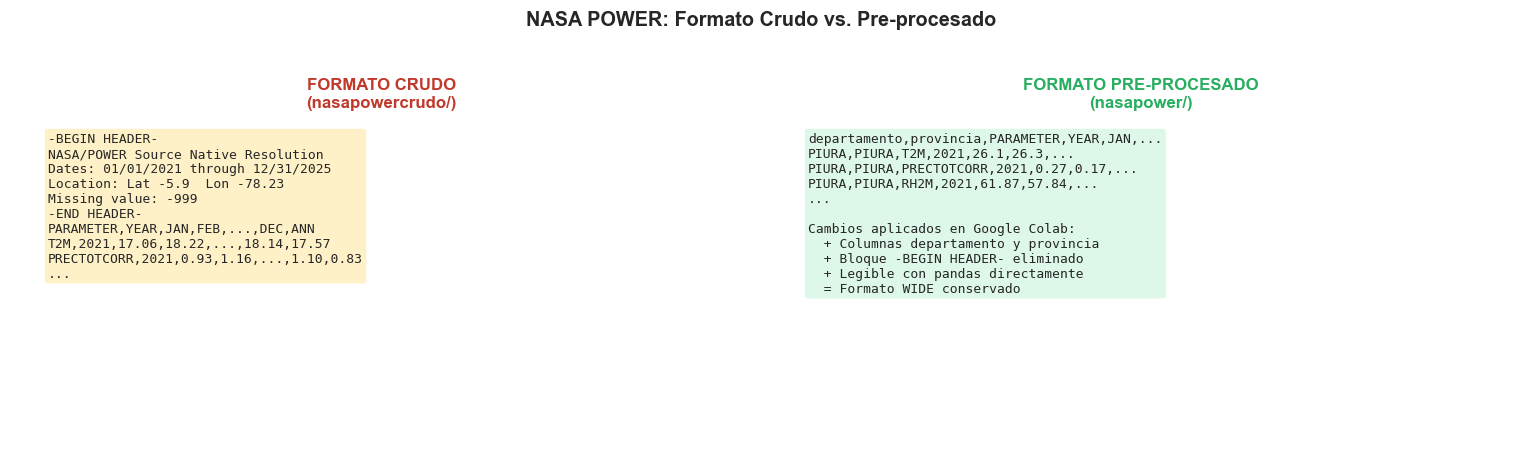

Guardado: pipeline/output/03_eda/nasa_g7_crudo_vs_procesado.png


In [5]:
# ============================================================
# GRAFICO 7: Comparacion visual crudo vs procesado (tabla)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel izquierdo: formato crudo
axes[0].axis('off')
crudo_text = (
    '-BEGIN HEADER-\n'
    'NASA/POWER Source Native Resolution\n'
    'Dates: 01/01/2021 through 12/31/2025\n'
    'Location: Lat -5.9  Lon -78.23\n'
    'Missing value: -999\n'
    '-END HEADER-\n'
    'PARAMETER,YEAR,JAN,FEB,...,DEC,ANN\n'
    'T2M,2021,17.06,18.22,...,18.14,17.57\n'
    'PRECTOTCORR,2021,0.93,1.16,...,1.10,0.83\n'
    '...'
)
axes[0].text(0.05, 0.95, crudo_text, transform=axes[0].transAxes,
             fontsize=8.5, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#ffeeba', alpha=0.8))
axes[0].set_title('FORMATO CRUDO\n(nasapowercrudo/)', fontsize=11, fontweight='bold', color='#c0392b')

# Panel derecho: formato procesado
axes[1].axis('off')
proc_text = (
    'departamento,provincia,PARAMETER,YEAR,JAN,...\n'
    'PIURA,PIURA,T2M,2021,26.1,26.3,...\n'
    'PIURA,PIURA,PRECTOTCORR,2021,0.27,0.17,...\n'
    'PIURA,PIURA,RH2M,2021,61.87,57.84,...\n'
    '...\n'
    '\n'
    'Cambios aplicados en Google Colab:\n'
    '  + Columnas departamento y provincia\n'
    '  + Bloque -BEGIN HEADER- eliminado\n'
    '  + Legible con pandas directamente\n'
    '  = Formato WIDE conservado'
)
axes[1].text(0.05, 0.95, proc_text, transform=axes[1].transAxes,
             fontsize=8.5, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#d5f5e3', alpha=0.8))
axes[1].set_title('FORMATO PRE-PROCESADO\n(nasapower/)', fontsize=11, fontweight='bold', color='#27ae60')

plt.suptitle('NASA POWER: Formato Crudo vs. Pre-procesado', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
out_g7 = OUTPUT['eda'] + 'nasa_g7_crudo_vs_procesado.png'
plt.savefig(out_g7, dpi=120, bbox_inches='tight')
plt.show()
print(f'Guardado: {out_g7}')


### Interpretación — Gráfico 7

**Qué muestra:** La diferencia entre el formato nativo de descarga de NASA POWER (izquierda) y el formato pre-procesado por el compañero en Google Colab (derecha).

**Implicación para el pipeline:** El pre-procesamiento fue un paso manual necesario que se realizó una sola vez para las 102 provincias. Este gráfico documenta ese trabajo y justifica por qué los archivos en `nasapower/` son el punto de entrada del pipeline, no los archivos en `nasapowercrudo/`.

**Implicación para el modelo:** La adición de columnas `departamento` y `provincia` es lo que permite hacer el JOIN con MIDAGRI e INDECI usando la llave geográfica. Sin ese pre-procesamiento, la integración multimodal no sería posible.


## 2.5 Gráfico 8 — Provincias por departamento


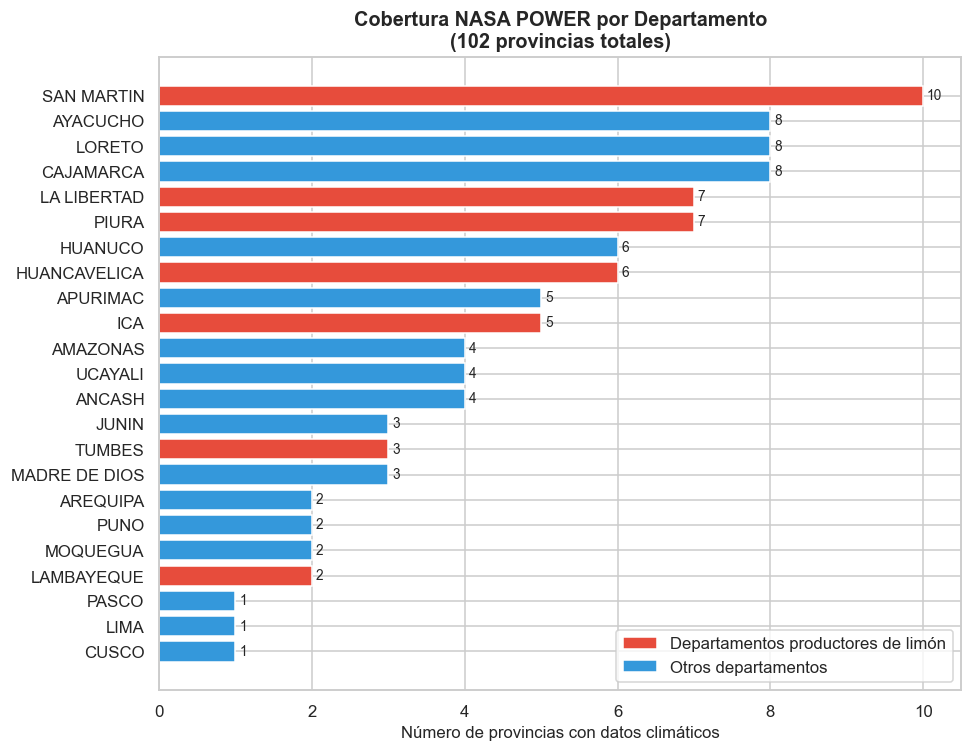

Guardado: pipeline/output/03_eda/nasa_g8_provincias_dpto.png


In [6]:
# ============================================================
# GRAFICO 8: Provincias por departamento
# ============================================================
prov_por_dpto = df_nasa_long.groupby('DEPARTAMENTO')['PROVINCIA'].nunique().sort_values(ascending=True)

# Resaltar departamentos limoneros
limoneros = ['PIURA','LA LIBERTAD','LAMBAYEQUE','ICA','TUMBES','SAN MARTIN']
colors = ['#e74c3c' if any(l in d.upper() for l in limoneros)
          else '#3498db' for d in prov_por_dpto.index]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(prov_por_dpto.index, prov_por_dpto.values, color=colors)
ax.set_xlabel('Número de provincias con datos climáticos', fontsize=11)
ax.set_title('Cobertura NASA POWER por Departamento\n(102 provincias totales)', fontsize=13, fontweight='bold')
for i, v in enumerate(prov_por_dpto.values):
    ax.text(v + 0.05, i, str(v), va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Departamentos productores de limón'),
                   Patch(facecolor='#3498db', label='Otros departamentos')]
ax.legend(handles=legend_elements)
plt.tight_layout()
out_g8 = OUTPUT['eda'] + 'nasa_g8_provincias_dpto.png'
plt.savefig(out_g8, dpi=120, bbox_inches='tight')
plt.show()
print(f'Guardado: {out_g8}')


### Interpretación — Gráfico 8

**Qué muestra:** Cuántas provincias tiene cobertura climática por departamento. Los departamentos limoneros aparecen en rojo.

**Implicación para el pipeline:** Los departamentos con más provincias tienen mayor representación en el dataset climático. Si un departamento productor de limón tiene pocas provincias con datos NASA, puede haber huecos en el merge con MIDAGRI.

**Implicación para el modelo:** La cobertura geográfica de NASA POWER determina directamente cuántas filas del dataset maestro tendrán variables climáticas completas. Provincias sin datos climáticos recibirán imputación en la Actividad 5.


## 2.6 Gráfico 9 — Serie temporal T2M para provincias clave


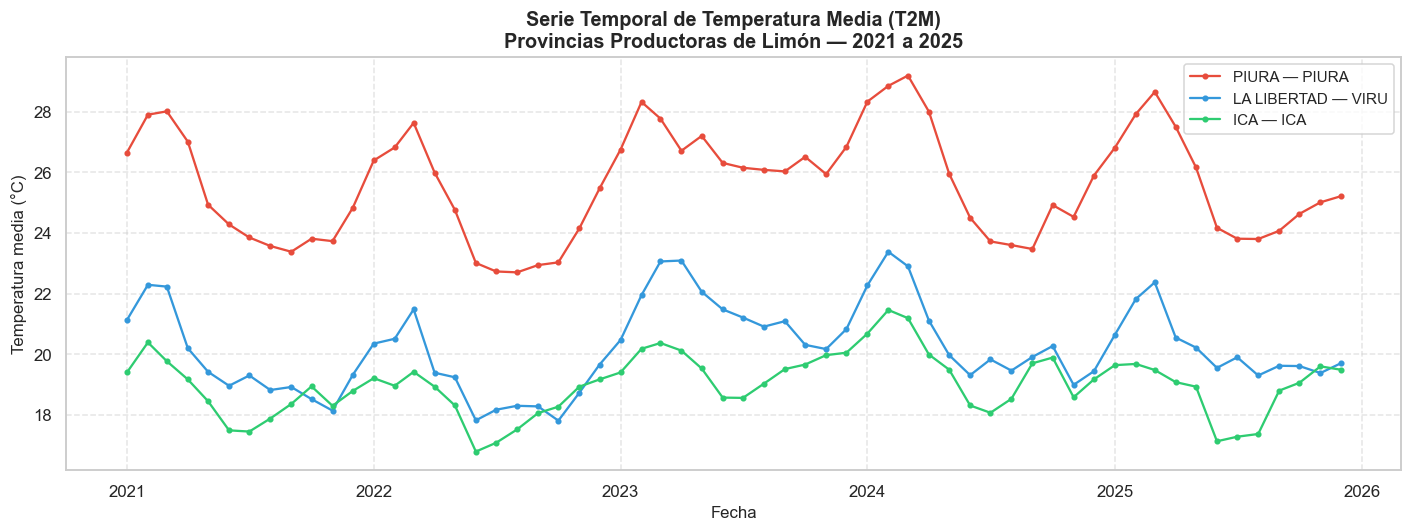

Guardado: pipeline/output/03_eda/nasa_g9_serie_t2m.png


In [7]:
# ============================================================
# GRAFICO 9: Serie temporal T2M para 3 provincias clave
# ============================================================
provincias_clave = [('PIURA','PIURA'), ('LA LIBERTAD','VIRU'), ('ICA','ICA')]
colores_prov = ['#e74c3c', '#3498db', '#2ecc71']

if 'T2M' in df_nasa_long.columns:
    fig, ax = plt.subplots(figsize=(13, 5))

    for (dpto, prov), color in zip(provincias_clave, colores_prov):
        mask = ((df_nasa_long['DEPARTAMENTO'].str.upper() == dpto) &
                (df_nasa_long['PROVINCIA'].str.upper() == prov))
        df_sub = df_nasa_long[mask].copy()
        if df_sub.empty:
            print(f'  Sin datos para {dpto}-{prov}')
            continue
        df_sub = df_sub.sort_values(['YEAR','MES'])
        df_sub['fecha'] = pd.to_datetime(
            df_sub['YEAR'].astype(str) + '-' + df_sub['MES'].astype(str).str.zfill(2) + '-01'
        )
        ax.plot(df_sub['fecha'], df_sub['T2M'], marker='o', markersize=3,
                linewidth=1.5, color=color, label=f'{dpto} — {prov}')

    ax.set_xlabel('Fecha', fontsize=11)
    ax.set_ylabel('Temperatura media (°C)', fontsize=11)
    ax.set_title('Serie Temporal de Temperatura Media (T2M)\nProvincias Productoras de Limón — 2021 a 2025', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    out_g9 = OUTPUT['eda'] + 'nasa_g9_serie_t2m.png'
    plt.savefig(out_g9, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Guardado: {out_g9}')
else:
    print('Columna T2M no encontrada en el dataset LONG.')


### Interpretación — Gráfico 9

**Qué muestra:** La evolución mensual de la temperatura media en las tres principales zonas productoras de limón del Perú entre 2021 y 2025.

**Implicación para el pipeline:** Permite detectar a simple vista si hay valores anómalos (picos o caídas abruptas) que podrían ser errores de medición. Cualquier anomalía visible aquí se investigará en la Actividad 4 (Calidad).

**Implicación para el modelo:** La estacionalidad visible en las curvas confirma que la temperatura tiene un patrón cíclico anual, lo que justifica incluirla como variable exógena en el LSTM-Attention. El modelo aprenderá a asociar ciertos rangos de temperatura con niveles de producción.


## 2.7 Gráfico 10 — Nulos por variable climática


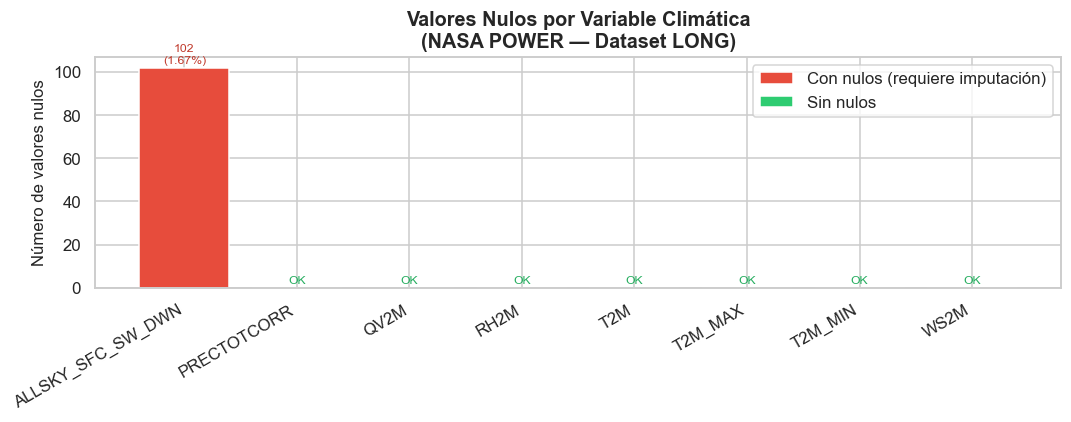

Guardado: pipeline/output/03_eda/nasa_g10_nulos_variables.png

Resumen de nulos:
  ALLSKY_SFC_SW_DWN           102 nulos (1.7%)  REQUIERE IMPUTACION
  PRECTOTCORR                   0 nulos (0.0%)  OK
  QV2M                          0 nulos (0.0%)  OK
  RH2M                          0 nulos (0.0%)  OK
  T2M                           0 nulos (0.0%)  OK
  T2M_MAX                       0 nulos (0.0%)  OK
  T2M_MIN                       0 nulos (0.0%)  OK
  WS2M                          0 nulos (0.0%)  OK


In [8]:
# ============================================================
# GRAFICO 10: Nulos por variable climatica
# ============================================================
vars_clima = [c for c in df_nasa_long.columns
              if c not in ['DEPARTAMENTO','PROVINCIA','YEAR','MES']]
nulos = df_nasa_long[vars_clima].isnull().sum().sort_values(ascending=False)
pct_nulos = (nulos / len(df_nasa_long) * 100).round(2)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in nulos.values]
bars = ax.bar(nulos.index, nulos.values, color=colors, edgecolor='white')
ax.set_ylabel('Número de valores nulos', fontsize=11)
ax.set_title('Valores Nulos por Variable Climática\n(NASA POWER — Dataset LONG)', fontsize=13, fontweight='bold')
ax.set_xticklabels(nulos.index, rotation=30, ha='right')

for bar, val, pct in zip(bars, nulos.values, pct_nulos.values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val}\n({pct}%)', ha='center', va='bottom', fontsize=8, color='#c0392b')
    else:
        ax.text(bar.get_x() + bar.get_width()/2, 1,
                'OK', ha='center', va='bottom', fontsize=8, color='#27ae60')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Con nulos (requiere imputación)'),
                   Patch(facecolor='#2ecc71', label='Sin nulos')]
ax.legend(handles=legend_elements)
plt.tight_layout()
out_g10 = OUTPUT['eda'] + 'nasa_g10_nulos_variables.png'
plt.savefig(out_g10, dpi=120, bbox_inches='tight')
plt.show()
print(f'Guardado: {out_g10}')
print()
print('Resumen de nulos:')
for var, n, p in zip(nulos.index, nulos.values, pct_nulos.values):
    estado = 'REQUIERE IMPUTACION' if n > 0 else 'OK'
    print(f'  {var:<25} {n:>5} nulos ({p:.1f}%)  {estado}')


### Interpretación — Gráfico 10

**Qué muestra:** El número de valores nulos por variable climática. Solo `ALLSKY_SFC_SW_DWN` (radiación solar) tiene nulos, correspondientes a los meses futuros (sep–dic 2025) para los que NASA aún no tiene datos.

**Implicación para el pipeline:** Los nulos de `ALLSKY_SFC_SW_DWN` se imputarán en la Actividad 5 usando interpolación lineal (son ≤ 4 meses consecutivos por provincia). Las demás variables están completas al 100%, lo que confirma la alta calidad del dataset NASA.

**Implicación para el modelo:** Un dataset climático casi sin nulos reduce la necesidad de imputación y minimiza el riesgo de introducir sesgos artificiales en las variables de entrada del LSTM-Attention.


## 2.8 Exportación del raw


In [9]:
# ============================================================
# 2.8 Exportar nasa_long_raw.csv
# ============================================================
out_nasa = OUTPUT['lectura'] + 'nasa_long_raw.csv'
df_nasa_long.to_csv(out_nasa, index=False, encoding='utf-8-sig')
print(f'Exportado: {out_nasa}')
print(f'Shape: {df_nasa_long.shape}')
print(f'Columnas: {df_nasa_long.columns.tolist()}')
print()
print('[ACTIVIDAD 2 - NASA] COMPLETADA.')
print('  Siguiente paso: pipeline/fuentes/nasa/actividad_03_eda_nasa.ipynb')


Exportado: pipeline/output/02_lectura/nasa_long_raw.csv
Shape: (6120, 12)
Columnas: ['DEPARTAMENTO', 'PROVINCIA', 'YEAR', 'MES', 'ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'QV2M', 'RH2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'WS2M']

[ACTIVIDAD 2 - NASA] COMPLETADA.
  Siguiente paso: pipeline/fuentes/nasa/actividad_03_eda_nasa.ipynb
